# Face Detection with Haar Cascades

**Note: This is face *detection* NOT face *recognition*. We are only detecting if a face is in an image, not who the face actually is. That requires deep learning.**

## 1) Load and Display Images

- Step 1: Import necessary packages: numpy, cv2, matplotlib.pyplot
- Step 2: Load grayscale images using cv2.imread() with flag 0
- Step 3: Display images using plt.imshow() with cmap='gray'

In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
%matplotlib inline

## Images

In [2]:


 with_glass = cv2.imread('image_02.png', 0)
 with_out_glass = cv2.imread('image_01.png', 0)
 group_photo = cv2.imread('image_03.png', 0)





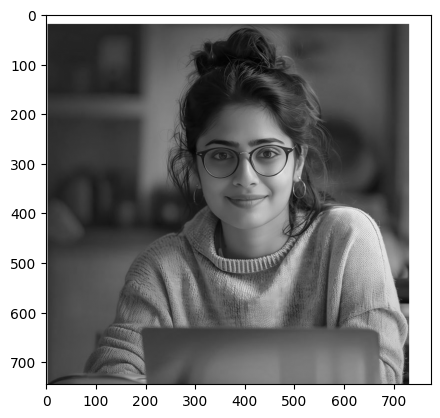

In [3]:
plt.imshow(with_glass,cmap='gray')

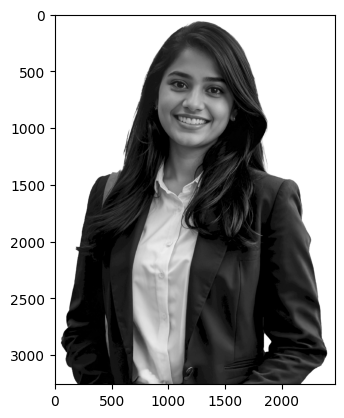

In [4]:
plt.imshow(with_out_glass,cmap='gray')

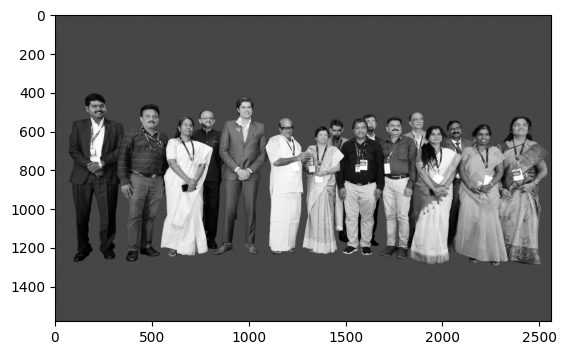

In [5]:
plt.imshow(group_photo,cmap='gray')

## II) Load Haar Cascade Classifiers

- Step 1: Load face and eye cascade XML files

## Face Detection

In [6]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

## III) Perform Face Detection in Images

- Step 1: Define a function detect_face() that copies the input image
- Step 2: Use face_cascade.detectMultiScale() to detect faces
- Step 3: Draw white rectangles around detected faces with thickness 10
- Step 4: Return the processed image with rectangles

In [7]:
def detect_face(img):

    # Load Haar Cascade classifier
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )

    # Create copy of image
    face_img = img.copy()

    # Detect faces
    face_rects = face_cascade.detectMultiScale(
        face_img,
        scaleFactor=1.2,
        minNeighbors=5
    )

    # Draw rectangles around faces
    for (x, y, w, h) in face_rects:
        cv2.rectangle(face_img, (x, y), (x+w, y+h), (255,255,255), 10)

    return face_img

In [8]:
result = detect_face(with_glass)

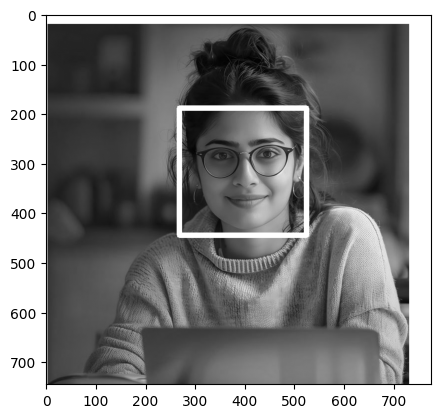

In [9]:
plt.imshow(result,cmap='gray')

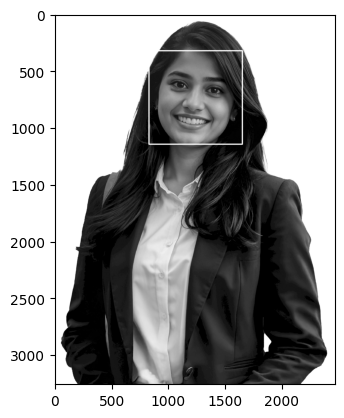

In [10]:
result = detect_face(with_out_glass)
plt.imshow(result,cmap='gray')

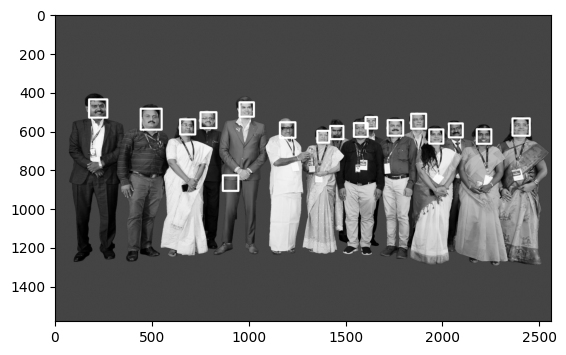

In [11]:
# Gets errors!
result = detect_face(group_photo)
plt.imshow(result,cmap='gray')

In [12]:
def adj_detect_face(img):

    # Load Haar Cascade classifier
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )

    # Create copy of image
    face_img = img.copy()

    # Detect faces with adjusted parameters
    face_rects = face_cascade.detectMultiScale(
        face_img,
        scaleFactor=1.05,
        minNeighbors=3
    )

    # Draw rectangles around detected faces
    for (x, y, w, h) in face_rects:
        cv2.rectangle(face_img, (x, y), (x+w, y+h), (255,255,255), 10)

    return face_img

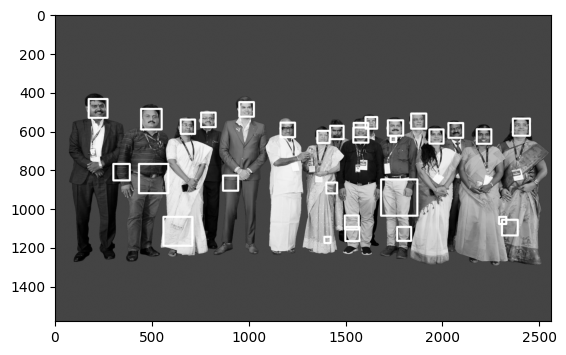

In [13]:
# Doesn't detect the side face.
result = adj_detect_face(group_photo)
plt.imshow(result,cmap='gray')

## IV) Perform Eye Detection in Images & Display Detection Results on Images

- Step 1: Define a function detect_eyes() that copies the input image
- Step 2: Use eye_cascade.detectMultiScale() to detect eyes
- Step 3: Draw white rectangles around detected eyes with thickness 10
- Step 4: Return the processed image with rectangles
- Step 5: Call detect_face() or detect_eyes() on loaded images
- Step 6: Use plt.imshow() with cmap='gray' to display images with detected regions highlighted

In [14]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

In [15]:
def detect_eyes(img):

    # Load eye cascade classifier
    eye_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_eye.xml'
    )

    # Create copy of image
    face_img = img.copy()

    # Detect eyes
    eyes = eye_cascade.detectMultiScale(
        face_img,
        scaleFactor=1.1,
        minNeighbors=5
    )

    # Draw rectangles around eyes
    for (x, y, w, h) in eyes:
        cv2.rectangle(face_img, (x, y), (x+w, y+h), (255,255,255), 10)

    return face_img

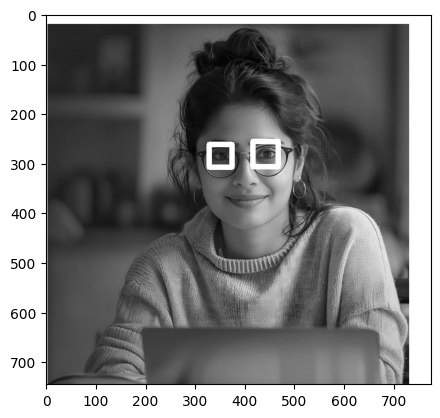

In [16]:
result = detect_eyes(with_glass)
plt.imshow(result,cmap='gray')

In [17]:
eyes = eye_cascade.detectMultiScale(with_out_glass) 

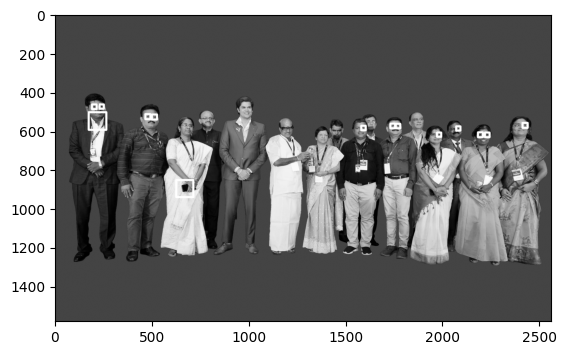

In [18]:
# White around the pupils is not distinct enough to detect eyes here!
result = detect_eyes(group_photo)
plt.imshow(result,cmap='gray')

## VI) Perform Face Detection on Real-Time Webcam Video

- Step 1: Capture video from webcam using cv2.VideoCapture(0)
- Step 2: Loop to continuously read frames from webcam
- Step 3: Apply detect_face() function on each frame
- Step 4: Display the video frame with rectangles around detected faces
- Step 5: Exit loop and close windows when ESC key (key code 27) is pressed
- Step 6: Release video capture and destroy all OpenCV windows

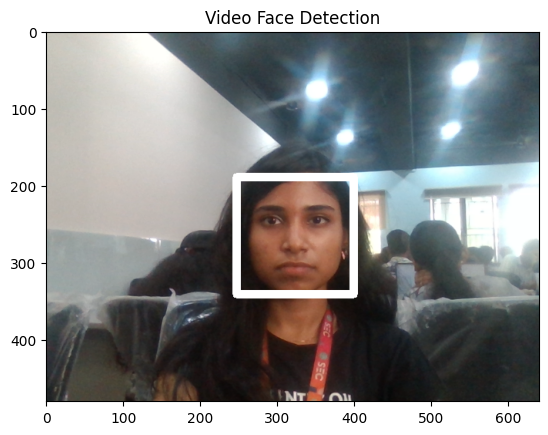

In [ ]:
cap = cv2.VideoCapture(0)

# Set up matplotlib
plt.ion()
fig, ax = plt.subplots()

ret, frame = cap.read(0)
frame = detect_face(frame)
im = ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title('Video Face Detection')

while True:
    ret, frame = cap.read(0)

    frame = detect_face(frame)

    # Update matplotlib image
    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.pause(0.10)

   

cap.release()
plt.close()